In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

from IPython import display

from matplotlib import pyplot as plt
import numpy as np
import math

In [2]:
R_on=500
R_off=25000
G_norm = 1/R_on - 1/R_off

In [3]:

class memristor():
                                                                                   #Kon= -70*10**(-6)
    def __init__(self, 
                 w_current,
                 Von = -0.6,
                 Voff = 0.6,
                 Ron=R_on,
                 Roff=R_off,
                 L=3*10**(-6),
                 Kon=-0.198*10**(-6), 
                 Koff=0.362*10**(-7),
                 Aon=2.357,
                 Aoff=1.48,
                 a_on = 0.184*10**(-6),
                 a_off = 0.6*10**(-9),
                 x_c = 0.248*10**(-5),
                 x_c_on = 0.19*10**(-6)):

        self.w_current = w_current
        self.V_on = Von
        self.V_off = Voff
        self.R_on = Ron
        self.R_off = Roff
        self.x_off = L
        self.x_on = 0
        self.x = self.x_current(self.w_current)
        self.K_on=Kon
        self.K_off=Koff
        self.Alpha_on=Aon
        self.Alpha_off=Aoff
        self.R = np.exp(np.log(self.R_off/self.R_on) * (self.x - self.x_on)/(self.x_off - self.x_on)) * self.R_on
        self.G_norm = 1/Ron - 1/Roff
        self.a_on = a_on
        self.a_off = a_off
        self.x_c = x_c
        self.x_c_on = x_c_on
        
    def Res(self, InVolt, dt):
        
            if (InVolt >= self.V_off):
    
                dxdt = self.K_off*((InVolt/self.V_off-1)**self.Alpha_off)
    
            if (InVolt <= self.V_on):
    
                dxdt = self.K_on*((InVolt/self.V_on-1)**self.Alpha_on)
    
            if ((self.V_on < InVolt) and (InVolt < self.V_off)):
  
                dxdt=0
  
    
            if (InVolt >= 0):
           
                self.x = self.x + dt*dxdt*np.exp(-np.exp((self.x - self.a_off)/self.x_c))
                #self.x = self.x + dt* dxdt
        
        
            if (InVolt < 0):
       
                self.x = self.x + dt*dxdt*np.exp(-np.exp((self.a_on - self.x)/self.x_c_on))
                #self.x = self.x + dt* dxdt
            
            if (self.x>=self.x_off):

                dxdt=0
                self.x = self.x_off
    
            if (self.x<=self.x_on):
    
                dxdt = 0
                self.x = self.x_on
    
            #return self.R_on + (self.x - self.x_on)*(self.R_off - self.R_on)/(self.x_off - self.x_on)
            self.R = np.exp(np.log(self.R_off/self.R_on) * (self.x - self.x_on)/(self.x_off - self.x_on)) * self.R_on
    
    def update(self, R: float):
    
        self.R = R
        
    def x_current (self, w_current: float):
       
        R = 1/(1/self.R_off + w_current*(1/self.R_on - 1/self.R_off))
        
        return self.x_on + (self.x_off - self.x_on)*(np.log(R/self.R_on))/(np.log(self.R_off/self.R_on))

    def reset(self):  
         
        self.x = self.x_current(self.w_current)
        self.R = np.exp(np.log(self.R_off/self.R_on) * (self.x - self.x_on)/(self.x_off - self.x_on)) * self.R_on
    

In [4]:
dt = 1.0

#memr = memristor()

impulse_length = 400.0  #длительность импулсьа
impulse_amplitude = 0.5
impulse_amplitude_2 = 0.5

k = 0.5
 
                                     

In [5]:
def impulse_curve_2(t, dt, impulse_length, impulse_amplitude): #производная импульса
        
        impulse_value = impulse_amplitude/(impulse_length - 2 * dt)/k #производная в точках, не находящихся в середине импульса
    
        impulse_bias =  (2*impulse_amplitude *(abs(t - (impulse_length * k)) < dt/2) + 2*impulse_amplitude*(abs(t - (impulse_length * k)) == dt/2)*(t < impulse_length * k))/dt
                                               
        impulse = (-impulse_value) * (t > 0) * (t < impulse_length * k) + (-impulse_value)/((1-k)/k)  * (t > impulse_length * k) + impulse_bias
        
        #impulse = (-impulse_value)/(1-k)  * (t > impulse_length * k) + impulse_bias
        
        impulse *= -1
        
        return impulse
    

In [6]:

def impulse_curve_2_integrated(k, dt, impulse_length, impulse_amplitude): # сам импульс, принимает не время, а номер шага по времени и dt, это чтобы при операциях с float меньше терять
    #информацию
    
    current = 0
    
    for i in range (k + 1):
    
        current +=  dt * impulse_curve_2(i*dt, dt, impulse_length, impulse_amplitude)
        
        #print(i*dt,'\n')
        if (i * dt >= impulse_length):
            current = 0
        
    return current
    

Text(0, 0.5, 'V, В')

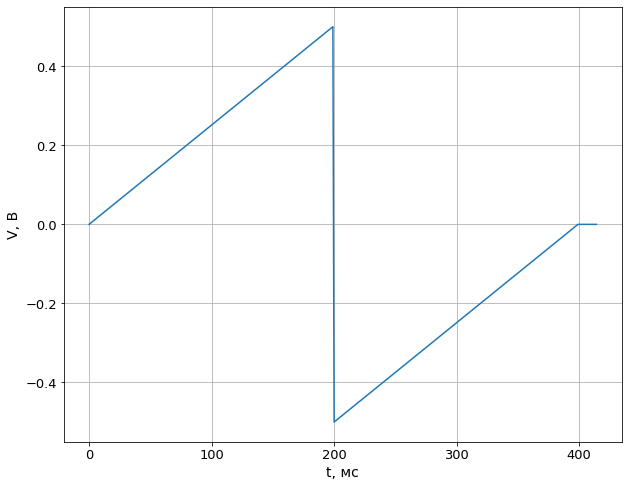

In [7]:
#строим импульс
ar = []

for i in range(int(impulse_length/dt) + 15):
    #if i:
    #    ar.append(impulse_curve_2(i * dt, dt) * dt + ar[i-1])
    #else:
    #    ar.append(impulse_curve_2(i * dt, dt) * dt)
    
    ar.append(impulse_curve_2_integrated(i , dt, impulse_length, impulse_amplitude))
    #print(i*dt,'\n')
    
      
#print(ar)    
fig_w_0 = plt.figure(figsize=(10,8))
gr_1 = fig_w_0.add_subplot(1,1,1)
gr_1.plot(np.arange(int(impulse_length/dt) + 15), ar)
gr_1.grid()
#plt.show()
#ar.clear()
gr_1.tick_params(axis='both', which='major', labelsize=13)
gr_1.set_xlabel('t, мс',fontsize = 14)
gr_1.set_ylabel("V, В",fontsize = 14)

In [8]:
import torch

time:  -100   0.004882185575231365
time:  -50   0.10506566986178864
time:  50   0.02577461242639434
time:  100   0.03779744461970251
Error for  0.489795918367347 :  0.04337997812077922
time:  -100   0.14769477849718665
time:  -50   0.010245745697850299
time:  50   0.0003078392086376594
time:  100   0.07131997168788311
Error for  0.10714285714285715 :  0.05739208377288943
time:  -100   1.086108117496903
time:  -50   0.750275931640436
time:  50   0.007737981032190616
time:  100   0.9052028397751294
Error for  0.06462585034013606 :  0.6873312174861648


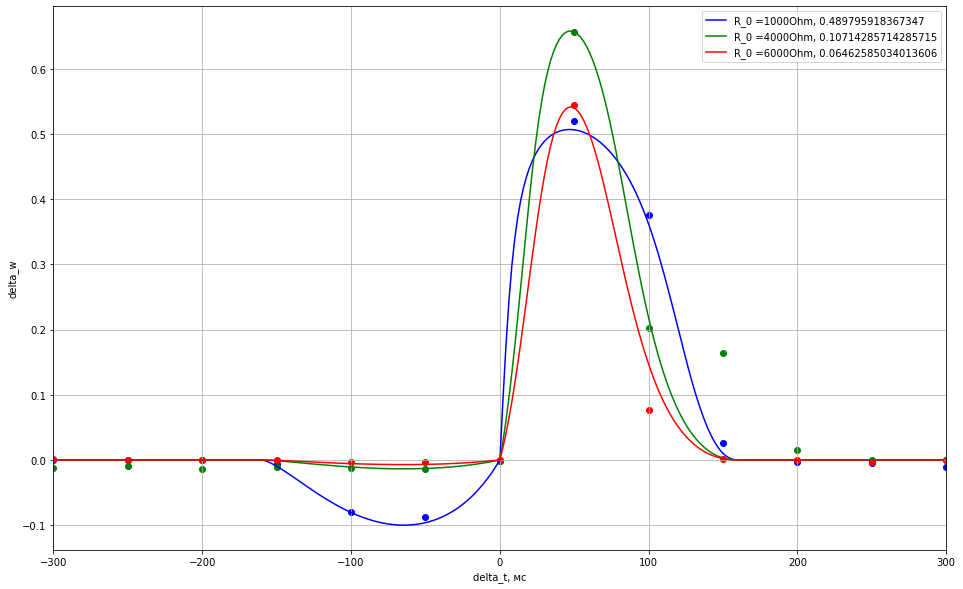

In [9]:
#Промеряем STDP
step = 2.0
delta_w = []
w_temp = []
colors_P = ['b','g','r','m','c','y','k','orange']
fl = open("C:/Users/Всеволод/Desktop/наука/origin_data.txt",'r')

plt.figure(figsize=(16,10))

pi = 3.1415/impulse_length

num = [1000,4000,6000,7000] 

for i in range (0,3):
    
    w_current = (1/num[i] - 1/R_off)/G_norm
    
    memr = memristor(w_current, Ron = R_on, Roff = R_off)
    
    
    for count in range(int(-300/dt), int(300/dt), int(step/dt)):
    
        delta_t = count * dt
    
        R_c = memr.R
    
        for t_s in range( 0 , int((impulse_length + abs(delta_t))/dt)):
        
            t = t_s * dt
         
        #R_c = memr.R
            if (delta_t > 0):
                memr.Res(impulse_curve_2_integrated(t_s, dt, impulse_length, impulse_amplitude)*(t<=impulse_length) - impulse_curve_2_integrated(int(( t - delta_t)/dt), dt,impulse_length, impulse_amplitude_2)*(t>=abs(delta_t)), dt) 
            
        #memr.Res(np.sin(t*2*pi)*(t<=impulse_length) + np.sin((t - delta_t)*2*pi)*(t>=abs(delta_t)), dt)
        
            else:
                memr.Res(impulse_curve_2_integrated(int(( t - abs(delta_t))/dt), dt, impulse_length, impulse_amplitude)*(t>=abs(delta_t)) - impulse_curve_2_integrated(t_s, dt,impulse_length, impulse_amplitude_2)*(t<=impulse_length), dt)
        #____________
        # print(memr.R," ",R_c)
        #___________
        delta_w_current = (1/memr.R - 1/R_c)/memr.G_norm
        
        delta_w.append(delta_w_current)  
        memr.reset()
     
    w_temp = fl.readline().split()
    
    for z in range(0,len(w_temp)):
    
        try:
            
            w_temp[z] = float(w_temp[z].split(',')[0] + '.' + w_temp[z].split(',')[1])
            
        except IndexError:
            
            w_temp[z] = float(w_temp[z])
            
        w_temp[z] = ((w_temp[z]/100)*(1/num[i]))/G_norm
        
    plt.plot([time for time in range(int(-300/dt), int(300/dt), int(step/dt))], delta_w, color=colors_P[i],label= ("R_0 ="+str(num[i])+"Ohm, "+str((1/num[i] - 1/R_off)/G_norm)))
    plt.scatter([times for times in range(int(-500/dt), int(500/dt) + 1, int(50/dt))], w_temp , color=colors_P[i] )
    #plt.plot(delta_t, delta_w_STDP1, label='с+', color='r')
    
    Err = 0
    index_temp = 0
    number = 0
    for time in range(int(-500/dt), int(200/dt), int(50/dt)):

        if ((delta_w[int((time+300)/step)]!=0) and (time>-150) and (time<150)):
            
            number+=1
            print("time: ",time," ",abs((w_temp[index_temp] - delta_w[int((time+300)/step)])/w_temp[index_temp]))
            Err+= abs((w_temp[index_temp] - delta_w[int((time+300)/step)])/w_temp[index_temp])
                
        index_temp+=1
        
    Err = Err/number
    print("Error for ", w_current,": ", Err)
    
    #delta_w.append('\n')
    #fl.writelines(delta_w)
    delta_w.clear()
    w_temp.clear()
    
fl.close()
plt.ylabel('delta_w')
plt.xlabel('delta_t, мс')
#plt.legend(loc='best')
plt.xlim(-300, 300)
plt.grid()
plt.legend(loc="best")
plt.show()    

In [10]:
mem1 = memristor(0.49, Ron = R_on, Roff = R_off)
print(mem1.x_current(0.49))

5.312447750772889e-07
